# Variant functional consequences

This notebook provides a summary of the functional consequequences in GWAS and molQTL credible set lead variants.

Requirements:
- qualified lead variant effect

## Setup


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import plotnine as p9
from gentropy.common.session import Session
from pyspark.ml.feature import Bucketizer
from pyspark.sql import DataFrame, Window
from pyspark.sql import functions as f
from pyspark.sql import types as t

from manuscript_methods import OpenTargetsTheme, group_statistics
from manuscript_methods.datasets import LeadVariantEffect
from manuscript_methods.ve import SingleVariantEffectMethod, VariantEffect


Loading BokehJS ...

/Users/ss60/Projects/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
# Input paths and parameters
session = Session(extended_spark_conf={"spark.driver.memory": "40G"})
qualified_replicated_lve_path = "../../../data/intermediate_files/qualified_lead_variant_effect"
REM = 8
PAV_THRESHOLD = 0.66


# Output paths
ds_pav_path = "../../../data/plots/02-variant-effects/pav-maf-qualified-replicated-lve.tsv"
ds_abeta_path = "../../../data/plots/02-variant-effects/abeta-maf-qualified-replicated-lve.tsv"


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/16 15:42:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
session.spark


## Prepare data for plotting

This section prepares datasets for plotting the functional consequences of lead variants.
This includes
- most severe consequence score from VEP transcript consequences assigned to transcript in the variant proximity
- `proteinAltering` variant (PAV) status based on consequence score filtering
- `absEstimatedBeta` from `rescaledStatistics`
- `geneId` for QTL variants and `diseaseIds` for GWAS variants (trait)


> [NOTE!] Due to the fact that lead variants - trait pairs are not unique (multiple signals can come from different cohorts/studies), we only keep the lead variants with the largest absolute effect size over disease/geneId to prevent double counting.

In [4]:
print("Number of qualified & replicated lead variant effects")
dataset = LeadVariantEffect.from_parquet(session, qualified_replicated_lve_path)
w1 = Window.partitionBy("variantId", "partition").orderBy(f.col("absEstimatedBeta").desc())
w2 = Window.partitionBy("variantId", "partition").orderBy(f.col("consequenceScore").desc())

effect_data = (
    dataset.df.select(
        f.col("variantId"),
        f.col("geneId"),
        f.concat_ws(",", f.sort_array(f.array_distinct(f.col("diseaseIds")))).alias("diseaseIds"),
        VariantEffect(f.col("variantEffect"))
        .filter_effect_by_method(SingleVariantEffectMethod.VEP)
        .normalised_score.alias("vepScore"),
        f.col("majorLdPopulationMaf.value").alias("maf"),
        f.col("rescaledStatistics.directionOfEffect").alias("directionOfEffect"),
        f.col("rescaledStatistics.absEstimatedBeta").alias("absEstimatedBeta"),
        f.col("studyStatistics.studyType").alias("studyType"),
        f.col("leadVariantConsequence.mostSevereConsequence.transcriptConsequence.consequenceScore").alias(
            "consequenceScore"
        ),
    )
    .withColumn("partition", f.concat_ws(",", f.coalesce(f.col("geneId"), f.col("diseaseIds")), f.col("studyType")))
    .withColumn("consequenceScore", f.round(f.coalesce(f.col("consequenceScore"), f.col("vepScore")), 3))
    .withColumn(
        "isProteinAltering", f.when((f.col("consequenceScore") >= PAV_THRESHOLD), 1).otherwise(0).cast(t.ShortType())
    )
    # Since we have many variantId-diseaseId pairs with different effect sizes (due to multiple studies), to prevent double counting,
    # we only keep the one with the largest absolute beta
    .withColumn("hasLargestAbsBeta", f.row_number().over(w1) == 1)
    .withColumn("hasLargestVariantEffect", f.row_number().over(w2) == 1)
    .withColumn("uniqueSignal", f.row_number().over(w1) == 1)
    .withColumn("largestAbsBetaDuplicationCount", f.count("*").over(w1))
    .withColumn("largestVariantEffectDuplicationCount", f.count("*").over(w2))
    .withColumn(
        "effectAligned",
        f.when(f.col("hasLargestAbsBeta") & f.col("hasLargestVariantEffect"), f.lit(True))
        .otherwise(f.lit(False))
        .cast(t.ShortType()),
    )
    .drop("vepScore")
    .cache()
)

print(f"Before tranformations - {dataset.df.count():,}")
effect_data_count = effect_data.count()
print(f"After transformation - {effect_data_count:,}")
group_statistics(effect_data, "effectAligned").show()


Number of qualified & replicated lead variant effects
Before tranformations - 950,517


After transformation - 950,517


+-------------+------+-----+------------------+
|effectAligned| count|    %|        percentage|
+-------------+------+-----+------------------+
|            0|692710|72.88| 72.87718157592131|
|            1|257807|27.12|27.122818424078687|
+-------------+------+-----+------------------+



In [5]:
effect_data.printSchema()


root
 |-- variantId: string (nullable = true)
 |-- geneId: string (nullable = true)
 |-- diseaseIds: string (nullable = false)
 |-- maf: double (nullable = true)
 |-- directionOfEffect: short (nullable = true)
 |-- absEstimatedBeta: double (nullable = true)
 |-- studyType: string (nullable = true)
 |-- consequenceScore: double (nullable = true)
 |-- partition: string (nullable = false)
 |-- isProteinAltering: short (nullable = false)
 |-- hasLargestAbsBeta: boolean (nullable = false)
 |-- hasLargestVariantEffect: boolean (nullable = false)
 |-- uniqueSignal: boolean (nullable = false)
 |-- largestAbsBetaDuplicationCount: long (nullable = false)
 |-- largestVariantEffectDuplicationCount: long (nullable = false)
 |-- effectAligned: short (nullable = false)



In [6]:
effect_data.groupBy("isProteinAltering").count().show()


+-----------------+------+
|isProteinAltering| count|
+-----------------+------+
|                1| 44107|
|                0|906410|
+-----------------+------+



### MAF bucketing


In [9]:
def prepare_maf_bins(effect_data: DataFrame) -> DataFrame:
    """Prepare MAF bins using Bucketizer and return the transformed DataFrame."""
    bucketizer = Bucketizer()
    splits = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
    # splits = [round(v, 3) for v in np.linspace(0, 0.5, num=21)]
    print(f"Using following buckets {splits}")
    bucketizer.setSplits(splits)
    # Use "maf" column as input to bucketizer
    bucketizer.setInputCol("maf")
    # Output column will be "mafBin"
    bucketizer.setOutputCol("mafBin")
    # Throw error if invalid value - below or above the split bounds is found
    bucketizer.setHandleInvalid("error")

    # Expression to map the bucketizer output (which are zero-based indices) to actual bin ranges
    maf_bin_expr = f.when(f.lit(False), f.lit(None))
    for i in range(len(splits) - 1):
        maf_bin_expr = maf_bin_expr.when(
            f.col("mafBin") == i,
            f.struct(
                f.lit(f"{splits[i]}-{splits[i + 1]}").alias("mafBinRange"),
                f.lit(splits[i]).alias("mafBinLower"),
                f.lit(splits[i + 1]).alias("mafBinUpper"),
                f.lit(np.round((splits[i] + splits[i + 1]) / 2, 3)).alias("mafBinMidpoint"),
                f.lit(i).alias("mafBinIndex"),
            ),
        )

    ds = (
        bucketizer.transform(
            effect_data.select(
                "studyType",
                "maf",
                "isProteinAltering",
                "absEstimatedBeta",
            )
            .filter(f.col("absEstimatedBeta") < 3)
            # Drop duplicated lead variants which have lower vep score then the highest
            .filter(f.col("hasLargestVariantEffect"))
        )
        # Since the output of the bucektizer are the zero-based indices of the bins, we cast the mafBin to IntegerType
        # And we get the actual bin ranges using maf_expression
        .withColumn("mafBin", f.col("mafBin").cast(t.IntegerType()))
        .withColumn("mafBin", maf_bin_expr)
        .cache()
    )

    # Sanity check - assert that the number of bins is the same as splits - 1
    num_bins = ds.select("mafBin.mafBinIndex").distinct().count()
    assert num_bins == (len(splits) - 1), f"Expected {len(splits) - 1} bins but found {num_bins}"
    return ds


### PAV proportion vs MAF bins dataset

In [10]:
w_pve = Window.partitionBy("studyType").orderBy("mafBin.mafBinIndex")  # .rangeBetween(-1, 1)
# Since we are using the transcript-level annotations for protein-altering variants,
# we would like to see the maximum vep score effect per variant
pav_lve = effect_data.filter(f.col("hasLargestVariantEffect"))

pav_lve.groupBy("hasLargestVariantEffect").count().show()  # Sanity check

# Expressions for protein-altering variant statistics within each MAF bin
total_variants_in_bucket = f.count(f.lit(1)).over(w_pve)
altering_variants_in_bucket = f.sum(f.col("isProteinAltering")).over(w_pve)
nonaltering_variants_in_bucket = total_variants_in_bucket - altering_variants_in_bucket
pav_proportion = f.avg(f.col("isProteinAltering")).over(w_pve)  # We can do mean as isProteinAltering is 0/1
pav_stderr = f.sqrt(pav_proportion * (1 - pav_proportion) / total_variants_in_bucket)  # ([p * (1 - p) ]/ n)
pav_ci_lower = pav_proportion - 1.96 * pav_stderr
pav_ci_upper = pav_proportion + 1.96 * pav_stderr

# Building the final dataset for PAV vs MAF bins
ds_pav = (
    prepare_maf_bins(pav_lve)
    .withColumn(
        "PAV",
        f.struct(
            altering_variants_in_bucket.alias("nAlteringInBucket"),
            nonaltering_variants_in_bucket.alias("nNonAlteringInBucket"),
            total_variants_in_bucket.alias("nTotalInBucket"),
            pav_proportion.alias("proportionInBucket"),
            pav_stderr.alias("proportionInBucketStderr"),
            pav_ci_lower.alias("proportionInBucketCILower"),
            pav_ci_upper.alias("proportionInBucketCIUpper"),
        ),
    )
    .drop("absEstimatedBeta", "maf", "isProteinAltering")
    .dropDuplicates()
    .select("studyType", "PAV.*", "mafBin.*")
    .orderBy(f.asc("studyType"), f.asc("mafBinIndex"))
    .cache()
)
print(f"Found {ds_pav.select('mafBinRange').distinct().count()} bins")
ds_pav.show()


+-----------------------+------+
|hasLargestVariantEffect| count|
+-----------------------+------+
|                   true|257807|
+-----------------------+------+

Using following buckets [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]


Found 7 bins
+------------+-----------------+--------------------+--------------+--------------------+------------------------+-------------------------+-------------------------+-----------+-----------+-----------+--------------+-----------+
|   studyType|nAlteringInBucket|nNonAlteringInBucket|nTotalInBucket|  proportionInBucket|proportionInBucketStderr|proportionInBucketCILower|proportionInBucketCIUpper|mafBinRange|mafBinLower|mafBinUpper|mafBinMidpoint|mafBinIndex|
+------------+-----------------+--------------------+--------------+--------------------+------------------------+-------------------------+-------------------------+-----------+-----------+-----------+--------------+-----------+
|    cis-pqtl|                7|                  10|            17|  0.4117647058823529|     0.11936462498726878|      0.17781004090730612|       0.6457193708573997|   0.0-0.01|        0.0|       0.01|         0.005|          0|
|    cis-pqtl|               67|                 207|           274


### Plot the PAV proportions across MAF bins ###

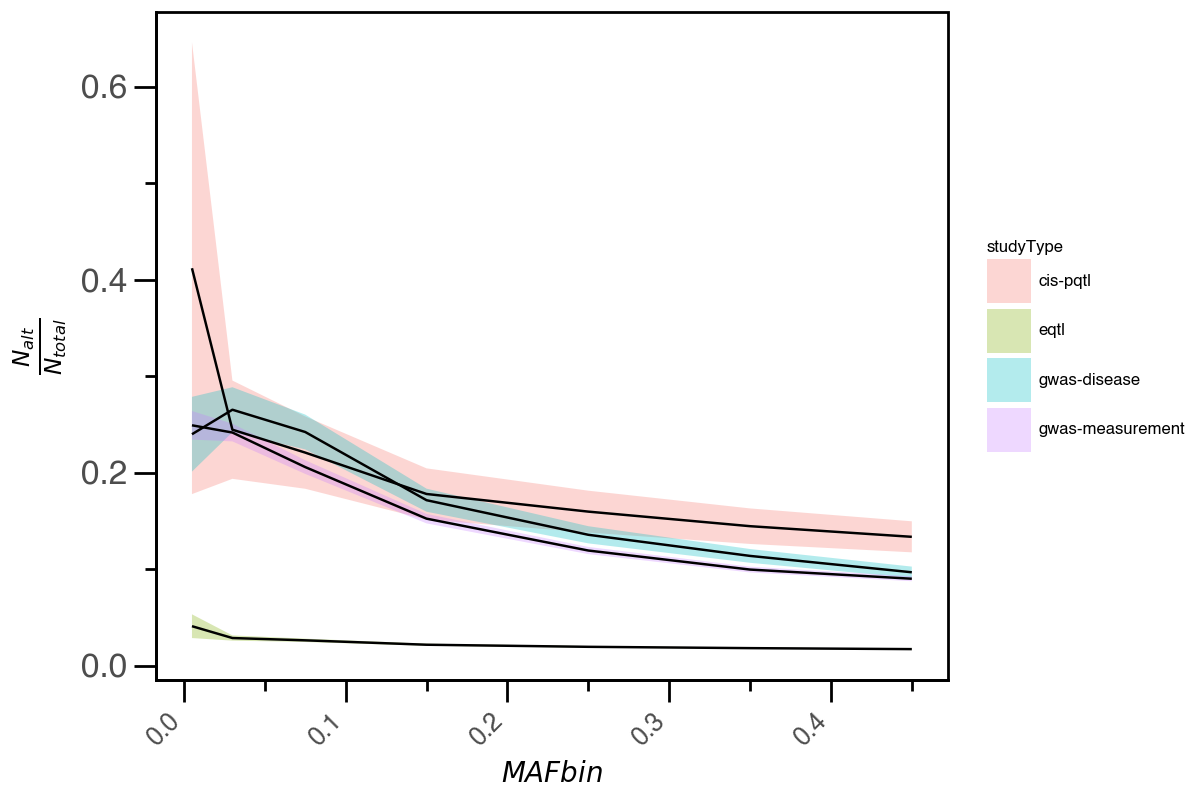

In [11]:
p2 = ds_pav.select(
    "proportionInBucket",
    "mafBinMidpoint",
    "studyType",
    "proportionInBucketCILower",
    "proportionInBucketCIUpper",
).toPandas() >> p9.ggplot(
    mapping=p9.aes(
        x="mafBinMidpoint",
        y="proportionInBucket",
        fill="studyType",
        ymin="proportionInBucketCILower",
        ymax="proportionInBucketCIUpper",
    ),
) + p9.geom_ribbon(alpha=0.3, color=None) + p9.labs(
    # title="Proportion of lead variant effects in replicated credible sets",
    x=r"$MAF bin$",
    y=r"$\frac{N_{alt}}{N_{total}}$",
) + p9.geom_line() + OpenTargetsTheme.categorical_theme(REM=6) + p9.theme(
    figure_size=(6, 4), legend_position="right"
) + p9.theme(axis_title_x=p9.element_text(size=10))
p2


### Abs beta vs MAF bins dataset

In [12]:
w_abeta = Window.partitionBy("studyType", "mafBin.mafBinIndex").orderBy()  # .rangeBetween(-1, 1)
# Since we are using the study-level effect,
# we would like to see the maximum abs beta per variant
# We also filter out variants with absEstimatedBeta >= 3 to avoid outliers
abeta_lve = effect_data.filter(f.col("hasLargestAbsBeta")).filter(f.col("absEstimatedBeta") < 3)

abeta_lve.groupBy("hasLargestAbsBeta").count().show()  # Sanity check

average_abs_beta = f.avg(f.col("absEstimatedBeta")).over(w_abeta)
min_abs_beta = f.min(f.col("absEstimatedBeta")).over(w_abeta)
max_abs_beta = f.max(f.col("absEstimatedBeta")).over(w_abeta)
std_abs_beta = f.std(f.col("absEstimatedBeta")).over(w_abeta)
total_abeta_variants_in_bucket = f.count(f.lit(1)).over(w_abeta)
abeta_stderr = std_abs_beta / f.sqrt(total_abeta_variants_in_bucket)
abeta_ci_lower = average_abs_beta - (f.lit(1.96) * abeta_stderr)
abeta_ci_upper = average_abs_beta + (f.lit(1.96) * abeta_stderr)

ds_abeta = (
    prepare_maf_bins(abeta_lve)
    .withColumn(
        "absBetaOverMafBin",
        f.struct(
            average_abs_beta.alias("avgAbsEstimatedBetaInBucket"),
            min_abs_beta.alias("minAbsEstimatedBetaInBucker"),
            max_abs_beta.alias("maxAbsEstimatedBetaInBucker"),
            std_abs_beta.alias("stdAbsEstimatedBetaInBucker"),
            total_abeta_variants_in_bucket.alias("nVariantsInBucket"),
            abeta_stderr.alias("absEstimatedBetaStderr"),
            abeta_ci_lower.alias("avgAbsEstimatedBetaCILower"),
            abeta_ci_upper.alias("avgAbsEstimatedBetaCIUpper"),
        ),
    )
    .drop("absEstimatedBeta", "maf", "isProteinAltering")
    .dropDuplicates()
    .select("studyType", "mafBin.*", "absBetaOverMafBin.*")
    .orderBy(f.asc("studyType"), f.asc("mafBinIndex"))
    .cache()
)
print(f"Found {ds_abeta.select('mafBinRange').distinct().count()} bins")
ds_abeta.show()


+-----------------+------+
|hasLargestAbsBeta| count|
+-----------------+------+
|             true|257807|
+-----------------+------+

Using following buckets [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]


Found 7 bins
+------------+-----------+-----------+-----------+--------------+-----------+---------------------------+---------------------------+---------------------------+---------------------------+-----------------+----------------------+--------------------------+--------------------------+
|   studyType|mafBinRange|mafBinLower|mafBinUpper|mafBinMidpoint|mafBinIndex|avgAbsEstimatedBetaInBucket|minAbsEstimatedBetaInBucker|maxAbsEstimatedBetaInBucker|stdAbsEstimatedBetaInBucker|nVariantsInBucket|absEstimatedBetaStderr|avgAbsEstimatedBetaCILower|avgAbsEstimatedBetaCIUpper|
+------------+-----------+-----------+-----------+--------------+-----------+---------------------------+---------------------------+---------------------------+---------------------------+-----------------+----------------------+--------------------------+--------------------------+
|    cis-pqtl|   0.0-0.01|        0.0|       0.01|         0.005|          0|         1.0605449762687527|        0.36196800726591827

### Plot the abs beta across MAF bins ###

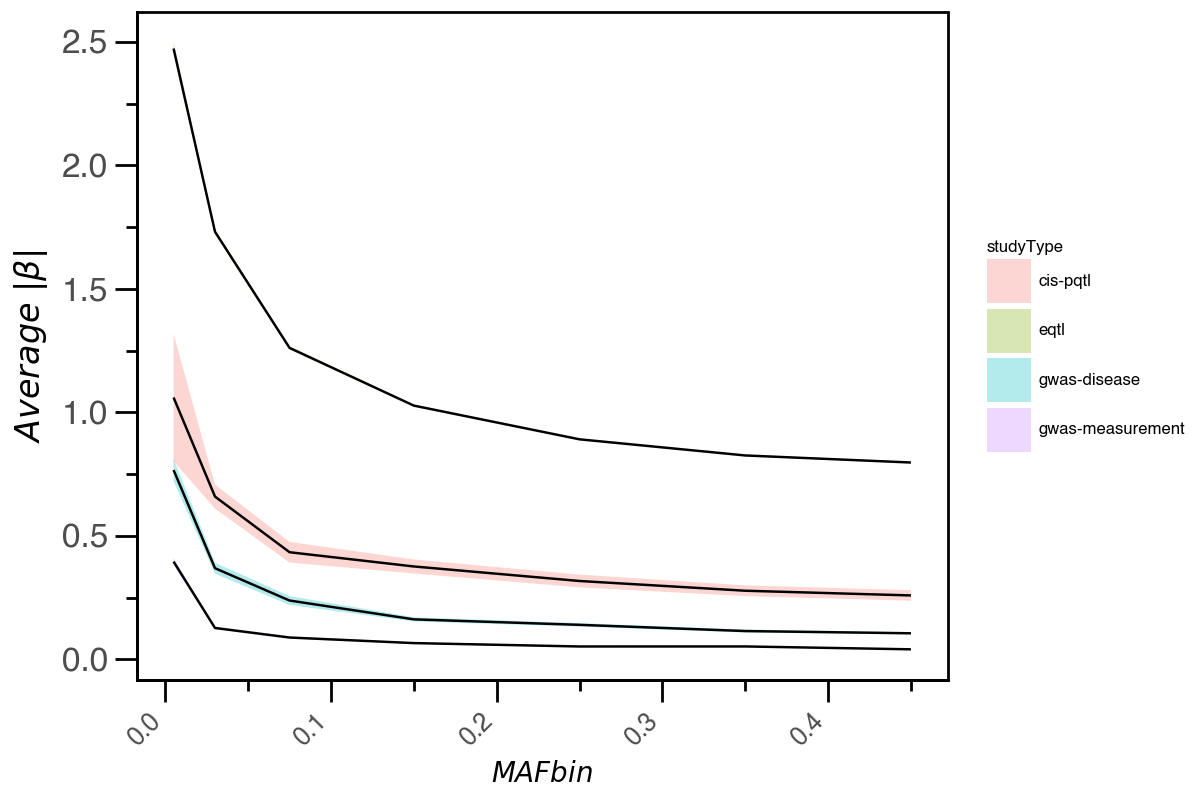

In [13]:
p3 = (
    ds_abeta.select(
        "avgAbsEstimatedBetaInBucket",
        "mafBinMidpoint",
        "studyType",
        "avgAbsEstimatedBetaCILower",
        "avgAbsEstimatedBetaCIUpper",
    ).toPandas()
    >> p9.ggplot(
        mapping=p9.aes(
            x="mafBinMidpoint",
            y="avgAbsEstimatedBetaInBucket",
            fill="studyType",
            ymin="avgAbsEstimatedBetaCILower",
            ymax="avgAbsEstimatedBetaCIUpper",
        ),
    )
    + p9.geom_ribbon(alpha=0.3, color=None)
    + p9.labs(  # title="Average absolute beta in MAF bins",
        x=r"$MAF bin$",
        y=r"$Average\ |\beta|$",
    )
    + OpenTargetsTheme.categorical_theme(REM=6)
    + p9.theme(figure_size=(6, 4), legend_position="right")
    + p9.theme(axis_title_x=p9.element_text(size=10))
    + p9.geom_line()
)
p3


### Save datasets for plotting 

In [14]:
## Save the dataset for plotting
Path(ds_abeta_path).parent.mkdir(parents=True, exist_ok=True)
Path(ds_pav_path).parent.mkdir(parents=True, exist_ok=True)
ds_abeta.toPandas().to_csv(ds_abeta_path, index=False, sep="\t")
ds_pav.toPandas().to_csv(ds_pav_path, index=False, sep="\t")
